In [1]:
import os
import numpy as np
import getdist
from getdist import plots, MCSamples
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib import cm
from pathlib import Path

In [2]:
def phi2_final(c):
    """
    Calculates phi^2_final based on c (xi).
    
    Formula:
    4 / (14*xi + 3*sqrt(4*xi*(xi + 9) + 9) + 9)
    """
    xi = c
    
    # 1. Calculate the term inside the square root
    # 4 * xi * (xi + 9) + 9
    sqrt_arg = 4.0 * xi * (xi + 9.0) + 9.0
    sqrt_term = np.sqrt(sqrt_arg)
    
    # 2. Calculate the denominator
    # 14*xi + 3*sqrt(...) + 9
    denominator = (14.0 * xi) + (3.0 * sqrt_term) + 9.0
    
    # 3. Final result
    return 4.0 / denominator

In [3]:
def phi2_initial(N, c):
    """
    Calculates phi^2_initial based on N and c (xi).
    
    Formula:
    (0.2 - 0.2 * exp(-6.66667 * xi * N) * (1. - 5. * xi * phi_f^2)^1.00002) / xi
    """
    # 1. Get phi_final squared
    # Ensure phi2_final(c) is defined as per your previous message
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the base term
    # (1. - 5. * xi * phi_f^2)
    base_term = 1.0 - 5.0 * xi * phi_f_sq
    
    # Safety check: base_term must be > 0 for fractional power
    # Given your previous constraints (1 > 5*xi*phi^2), this should be safe.
    if base_term <= 0:
        return np.nan
    
    # 4. Calculate the exponential part
    # exp(-6.66667 * xi * N)
    exp_part = np.exp(-6.66667 * xi * N)
    
    # 5. Calculate the numerator
    # 0.2 - 0.2 * exp_part * base_term^1.00002
    term2 = 0.2 * exp_part * (base_term**1.00002)
    numerator = 0.2 - term2
    
    # 6. Final result
    return numerator / xi

In [4]:
def ns_func(N, s, c):
    """
    Calculates the scalar spectral index n_s based on N and c (xi)
    using specific numerical constants.
    
    Formula:
    xi * ( (7.9997 / (1. * xi * phi_i^2 + 1.)) - 11.1109 ) - (1.77777 / phi_i^2) + 0.99985
    """
    # 1. Get phi_initial squared
    phi_i_sq = phi2_initial(N, c)
    
    # Safety check to avoid division by zero if phi_i_sq is very close to 0
    if phi_i_sq == 0:
        return np.nan

    # 2. Define xi
    xi = c
    
    # 3. Calculate the bracket term
    # (7.9997 / (1. * xi * phi_i^2 + 1.)) - 11.1109
    denom = (1.0 * xi * phi_i_sq) + 1.0
    bracket = (7.9997 / denom) - 11.1109
    
    # 4. Calculate the main terms
    term1 = xi * bracket
    term2 = 1.77777 / phi_i_sq
    term3 = 0.99985
    
    # 5. Final result
    return term1 - term2 + term3

In [5]:
def alpha_s_func(N, s, c):
    """
    Calculates the running of the scalar spectral index alpha_s 
    based on N and c (xi).
    """
    # 1. Get phi_final squared
    # Assuming phi2_final(c) is defined as per previous steps
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the base term (1 - 5 * xi * phi_f^2)
    base_term = 1.0 - 5.0 * xi * phi_f_sq
    
    # Safety check for domain
    if base_term <= 0:
        return np.nan

    # 4. Calculate the base exponential term
    # E = exp(6.66654 * xi * N)
    E = np.exp(6.66654 * xi * N)
    
    # Calculate powers of E used in the formula
    # Note: 13.3331 approx 2 * 6.66654
    # Note: 19.9996 approx 3 * 6.66654
    # We use the exact constants provided in the formula for precision
    E1 = E                                      # exp(6.66654 * xi * N)
    E2 = np.exp(13.3331 * xi * N)               # exp(13.3331 * xi * N)
    E3 = np.exp(19.9996 * xi * N)               # exp(19.9996 * xi * N)
    
    # Calculate powers of the base term
    B1 = base_term**0.999981
    B2 = base_term**1.99996
    B3 = base_term**2.99994
    
    # --- NUMERATOR ---
    # Term 1: 4.23253 * E^3 * B^3
    n1 = 4.23253 * E3 * B3
    
    # Term 2: 3.62839 * E^2 * B^2
    n2 = 3.62839 * E2 * B2
    
    # Term 3: -38.0945 * E * B
    n3 = -38.0945 * E1 * B1
    
    numerator = (xi**2) * (n1 + n2 + n3)
    
    # --- DENOMINATOR ---
    # The whole expression is squared
    
    # Term 1: 0.142857 * E^2 * B^2
    d1 = 0.142857 * E2 * B2
    
    # Term 2: -1. * E * B
    d2 = -1.0 * E1 * B1
    
    # Term 3: 0.857143
    d3 = 0.857143
    
    denominator = (d1 + d2 + d3)**2
    
    return numerator / denominator

Loading Planck...
Loading ACT...
Calculating trajectories...

Plot saved to alpha_s_vs_ns_2_3.pdf


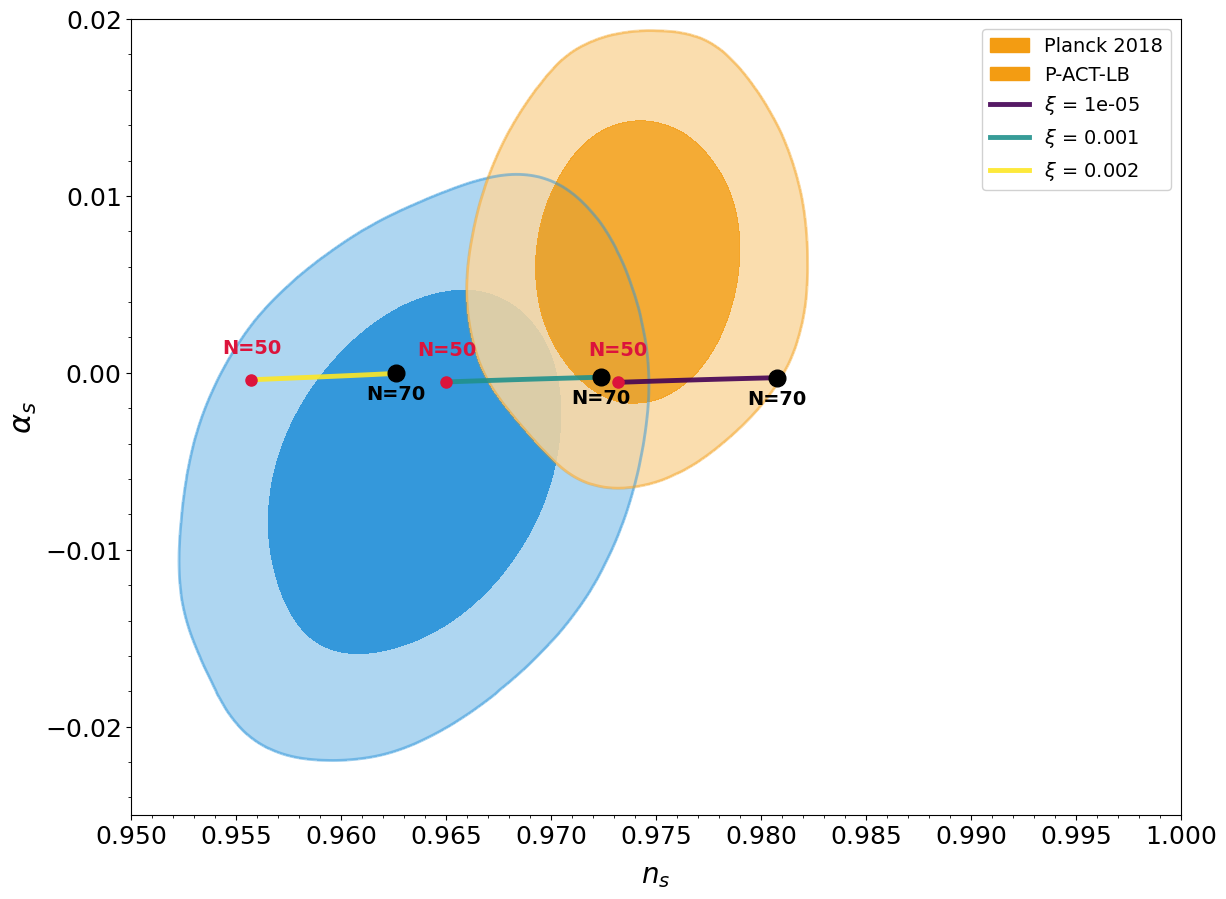

In [6]:
# --- 2. SETUP PATHS ---
notebook_dir = Path.cwd()

base_dir = notebook_dir.parents[1] / "data"
act_path = os.path.join(base_dir, 'p-actlite-l-b_nrun_camb', 'p-actlite-l-b_nrun_camb')
planck_path = os.path.join(base_dir, 'COM_CosmoParams_fullGrid_R3.01', 'base_nrun', 'plikHM_TTTEEE_lowl_lowE', 'base_nrun_plikHM_TTTEEE_lowl_lowE')

# --- 3. LOAD DATA ---
samples_to_plot = []

try:
    print("Loading Planck...")
    planck_samples = getdist.mcsamples.loadMCSamples(planck_path, settings={'ignore_rows': 0.3})
    planck_samples.updateSettings({'label': 'Planck 2018'}) 
    samples_to_plot.append(planck_samples)
except:
    print("Warning: Planck data not found.")

try:
    print("Loading ACT...")
    act_samples = getdist.mcsamples.loadMCSamples(act_path, settings={'ignore_rows': 0.3})
    act_samples.updateSettings({'label': 'P-ACT-LB'})
    samples_to_plot.append(act_samples)
except:
    print("Warning: ACT data not found.")

# --- 4. PLOT ---
if len(samples_to_plot) > 0:
    g = plots.get_single_plotter(width_inch=12, ratio=0.75)
    
    # Settings
    g.settings.num_plot_contours = 2
    g.settings.axes_fontsize = 18
    g.settings.lab_fontsize = 20
    g.settings.legend_fontsize = 15
    
    # COLORS: Planck (Grey), ACT (Blue)
    g.settings.solid_colors = ['#F39C12','#3498DB'] 

    g.plot_2d(samples_to_plot, param1='ns', param2='nrun', filled=True)
    ax = g.subplots[0,0]

    ax.set_ylabel(r'$\alpha_s$', fontsize=22)
    
    # --- 5. PLOT TRAJECTORIES ---
    print("Calculating trajectories...")
    s_fixed = 0.76
    #c_values = [0.00001,0.0005, 0.001, 0.0015, 0.003, 0.005, 0.007, 0.01, 0.02, 0.03, 0.04] 
    c_values = [0.00001,0.001,0.002]
    line_colors = [cm.viridis(i) for i in np.linspace(0, 1, len(c_values))]
    
    N_range = np.linspace(50, 70, 100) 
    
    for c, color in zip(c_values, line_colors):
        ns_line = []
        alpha_line = []
        for N in N_range:
            ns_line.append(ns_func(N, s_fixed, c))
            alpha_line.append(alpha_s_func(N, s_fixed, c))
        
        ax.plot(ns_line, alpha_line, color=color, lw=3.5, alpha=0.9, label=rf'$\xi$ = {c:.2g}')
        ax.plot(ns_line[0], alpha_line[0], 'o', color='crimson', markersize=8)
        ax.text(ns_line[0], alpha_line[0] + 0.0015, 'N=50', color='crimson', fontsize=14, weight='bold', ha='center')
        ax.plot(ns_line[-1], alpha_line[-1], 'o', color='black', markersize=12)
        ax.text(ns_line[-1], alpha_line[-1] - 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # Label N=50 and N=70
    ns_0 = ns_func(50, s_fixed, c_values[0])
    al_0 = alpha_s_func(50, s_fixed, c_values[0])
    #ax.text(ns_0, al_0 + 0.0015, 'N=50', color='black', fontsize=14, weight='bold', ha='center')

    ns_end = ns_func(70, s_fixed, c_values[0])
    al_end = alpha_s_func(70, s_fixed, c_values[0])
    #ax.text(ns_end, al_end + 0.0015, 'N=70', color='black', fontsize=14, weight='bold', ha='center')

    # --- 6. TICKS & LIMITS ---
    ax.set_xlim(0.95, 1.0)
    ax.set_ylim(-0.025, 0.02)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.005))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # --- 7. CREATE LEGEND MANUALLY (FIXED COLORS) ---
    
    # Manually create patches with the CORRECT colors
    planck_patch = mpatches.Patch(color='#F39C12', label='Planck 2018') # Grey
    act_patch = mpatches.Patch(color='#F39C12', label='P-ACT-LB')       # Blue
    
    # Get handles for the trajectory lines
    line_handles, line_labels = ax.get_legend_handles_labels()
    
    # Combine: [Data Patches] + [Line Handles]
    all_handles = [planck_patch, act_patch] + line_handles
    all_labels = ['Planck 2018', 'P-ACT-LB'] + line_labels

    
    ax.legend(handles=all_handles, labels=all_labels, loc='upper right', fontsize=14, framealpha=0.9)

    outfile = 'alpha_s_vs_ns_2_3.pdf'
    g.export(outfile, dpi=300)
    print(f"\nPlot saved to {outfile}")
else:
    print("No data loaded.")